# Phase 3 — Feature Engineering & Preprocessing
## Air Quality Intelligence Platform

Feature engineering is the process of transforming raw data into the inputs
a machine learning model can actually learn from. This is the phase that
most directly separates good models from mediocre ones.

**What we build in this notebook:**
1. Clean and type-correct all columns
2. Impute missing values using a time-series-appropriate strategy
3. Engineer time features (hour, day, month) with cyclical encoding
4. Engineer lag features — "what was the pollution N hours ago?"
5. Engineer rolling window features — "what is the recent trend?"
6. Define our classification target (AQI category)
7. Perform a time-aware train/validation/test split
8. Scale features and save everything to disk for Phase 4

**Why this notebook exists on its own (not merged with EDA):**
EDA is about *understanding* data. Feature engineering is about *transforming*
it. Keeping them separate makes both notebooks cleaner and makes it clear
to any reader that you understand the distinction.

In [22]:
# ── Standard library ──────────────────────────────────────────────
import os
import warnings

# ── Data manipulation ─────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation (for validation charts at the end) ─────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Scikit-learn: preprocessing tools ────────────────────────────
from sklearn.preprocessing import StandardScaler
# StandardScaler transforms each feature so it has mean=0 and std=1.
# This is required for many models. Tree-based models (Random Forest,
# XGBoost) don't strictly need it, but scaling never hurts and makes
# feature importance values more comparable.

from sklearn.model_selection import train_test_split
# We will NOT use this for our final split (we do a time-aware split manually),
# but we import it here for reference and possible use in validation.

# ── Settings ──────────────────────────────────────────────────────
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)

os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../outputs", exist_ok=True)

print("Imports complete ✓")

Imports complete ✓


In [23]:
# Load the cleaned CSV we produced in Phase 1.
df_raw = pd.read_csv("../data/raw/uci_air_quality_cleaned.csv")

# Re-parse DateTime — always needed when loading from CSV
df_raw["DateTime"] = pd.to_datetime(df_raw["DateTime"], errors="coerce")

# Sort chronologically — CRITICAL for time-series.
# If rows are out of order, lag features will be completely wrong.
df_raw = df_raw.sort_values("DateTime").reset_index(drop=True)

print(f"Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Date range: {df_raw['DateTime'].min().date()} → {df_raw['DateTime'].max().date()}")
print(f"\nColumn dtypes:")
print(df_raw.dtypes)

Loaded: 9,357 rows × 14 columns
Date range: 2004-01-04 → 2005-12-03

Column dtypes:
CO(GT)                  float64
PT08.S1(CO)             float64
NMHC(GT)                float64
C6H6(GT)                float64
PT08.S2(NMHC)           float64
NOx(GT)                 float64
PT08.S3(NOx)            float64
NO2(GT)                 float64
PT08.S4(NO2)            float64
PT08.S5(O3)             float64
T                       float64
RH                      float64
AH                      float64
DateTime         datetime64[us]
dtype: object


---
## Step 1 — Drop, Fix and Impute

### Which columns we keep and why

| Column | Type | Keep? | Reason |
|--------|------|-------|--------|
| CO(GT) | Target pollutant | Yes | Real CO concentration from reference analyser |
| PT08.S1(CO) | Sensor proxy | Yes | Metal-oxide sensor response — proxy for CO |
| NMHC(GT) | Pollutant | **No** | >90% missing — unusable |
| C6H6(GT) | Pollutant | Yes | Benzene — good predictor, well-populated |
| PT08.S2(NMHC) | Sensor proxy | Yes | Even though NMHC(GT) is dropped, the sensor still works |
| NOx(GT) | Pollutant | Yes | Nitrogen oxides — traffic indicator |
| PT08.S3(NOx) | Sensor proxy | Yes | — |
| NO2(GT) | **Our main target** | Yes | This is what we will predict |
| PT08.S4(NO2) | Sensor proxy | Yes | — |
| PT08.S5(O3) | Sensor proxy | Yes | Ozone proxy — useful indirect signal |
| T | Weather | Yes | Temperature — strong seasonal signal |
| RH | Weather | Yes | Relative humidity — affects pollutant dispersal |
| AH | Weather | Yes | Absolute humidity — derived from T and RH |
| DateTime | Index | Yes | Used to extract time features, then kept as index |

In [24]:
# Work on a copy — never modify the raw data in place.
# This is a professional habit: if something goes wrong, you can always
# reload df_raw and start the transformation again without re-running Phase 1.
df = df_raw.copy()

# ── Drop the NMHC(GT) column ──────────────────────────────────────
# It is >90% missing — imputing that many values would introduce more
# noise than signal. A model trained with it would learn from invented data.
df = df.drop(columns=["NMHC(GT)"], errors="ignore")
# errors="ignore" means: if the column doesn't exist, don't crash.

print(f"After dropping NMHC(GT): {df.shape[1]} columns remaining")

# ── Convert all sensor/pollutant columns to float ─────────────────
# From Phase 2 EDA we know these loaded as 'object' (string) dtype.
# pd.to_numeric with errors="coerce" converts each value to a number,
# replacing anything that can't be converted with NaN.
feature_cols = [c for c in df.columns if c != "DateTime"]
# List comprehension: every column except DateTime

for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    # We overwrite each column in-place with the numeric version.

print(f"\nDtypes after conversion:")
print(df.dtypes)

# Verify we now have proper floats
assert df[feature_cols].dtypes.apply(lambda t: np.issubdtype(t, np.number)).all(), \
    "Some columns are still non-numeric — check the data!"
# assert condition, message — raises AssertionError if condition is False.
# np.issubdtype(t, np.number) checks if dtype t is a numeric type.
# .all() checks that EVERY column passes the check.
print("\nAll feature columns confirmed numeric ✓")

After dropping NMHC(GT): 13 columns remaining

Dtypes after conversion:
CO(GT)                  float64
PT08.S1(CO)             float64
C6H6(GT)                float64
PT08.S2(NMHC)           float64
NOx(GT)                 float64
PT08.S3(NOx)            float64
NO2(GT)                 float64
PT08.S4(NO2)            float64
PT08.S5(O3)             float64
T                       float64
RH                      float64
AH                      float64
DateTime         datetime64[us]
dtype: object

All feature columns confirmed numeric ✓


In [25]:
# From Phase 2 we saw that all pollutant columns have extreme outliers.
# Some are real pollution events; others are sensor malfunctions (stuck sensors,
# electrical interference). We can't distinguish them, so we cap at the 99th
# percentile — a standard, defensible approach.
#
# "Capping" (also called "Winsorizing") replaces extreme values with the
# cap value rather than dropping them. This preserves the row count while
# preventing a handful of extreme values from dominating the model.

# These are the columns we cap — pollutants and sensor readings, not weather.
cap_cols = [
    "CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)",
    "PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)",
    "PT08.S4(NO2)", "PT08.S5(O3)"
]

print("Outlier capping summary:")
print(f"{'Column':<20} {'99th pct':>10} {'Max before':>12} {'Max after':>10}")
print("-" * 56)

for col in cap_cols:
    p99 = df[col].quantile(0.99)
    # .quantile(0.99) finds the value below which 99% of readings fall.
    # Anything above this is in the top 1% — our cap threshold.

    max_before = df[col].max()

    df[col] = df[col].clip(upper=p99)
    # .clip(upper=p99) replaces any value > p99 with p99.
    # Values below p99 are left unchanged.
    # We don't clip the lower bound because negative readings are already
    # handled — they were set to NaN when we replaced -200 in Phase 1.

    max_after = df[col].max()
    print(f"{col:<20} {p99:>10.2f} {max_before:>12.2f} {max_after:>10.2f}")

Outlier capping summary:
Column                 99th pct   Max before  Max after
--------------------------------------------------------
CO(GT)                     6.80        11.90       6.80
C6H6(GT)                  34.31        63.74      34.31
NOx(GT)                 1000.83      1479.00    1000.83
NO2(GT)                  245.52       339.70     245.52
PT08.S1(CO)             1706.53      2039.75    1706.53
PT08.S2(NMHC)           1649.10      2214.00    1649.10
PT08.S3(NOx)            1664.05      2682.75    1664.05
PT08.S4(NO2)            2365.13      2775.00    2365.13
PT08.S5(O3)             2093.70      2522.75    2093.70


In [26]:
print("Missing values BEFORE imputation:")
missing_before = df[feature_cols].isnull().sum()
print(missing_before[missing_before > 0])

# Forward-fill: carries the last valid observation forward in time.
# limit=3 means: only fill up to 3 consecutive missing hours.
# If a sensor is down for 4+ hours in a row, we don't fabricate data
# beyond 3 steps — longer gaps get filled by the median fallback.
#
# NOTE: In pandas 2.0+, fillna(method="ffill") was removed.
# The correct modern syntax is .ffill(limit=n) — a dedicated method
# that does exactly the same thing but with a cleaner API.
df[feature_cols] = df[feature_cols].ffill(limit=3)
# .ffill() propagates the last valid observation forward.
# limit=3 caps it at 3 consecutive fills — beyond that, NaN stays NaN
# so the median fallback below can handle genuinely long gaps.

# Fallback: fill any remaining NaNs (at the very start, or long gaps) with median.
for col in feature_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    # fillna(value) replaces NaN with the given scalar value.
    # .median() is robust to the outliers we capped earlier.

print("\nMissing values AFTER imputation:")
missing_after = df[feature_cols].isnull().sum()
remaining = missing_after[missing_after > 0]
if len(remaining) == 0:
    print("  No missing values remaining ✓")
else:
    print(remaining)

Missing values BEFORE imputation:
CO(GT)           1683
PT08.S1(CO)       366
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

Missing values AFTER imputation:
  No missing values remaining ✓


---
## Step 2 — Time Features with Cyclical Encoding

Raw time values like Hour=0 and Hour=23 are 23 units apart as integers.
But in reality, midnight (0) and 11pm (23) are just 1 hour apart — they
are adjacent on the 24-hour clock.

A model that sees Hour as a plain integer will make a systematic error:
it will think "late night" and "very early morning" are completely different
contexts, when they are actually very similar pollution-wise.

**The fix: cyclical encoding using sine and cosine.**

We map each hour onto a circle using:
- `sin(2π × hour / 24)` 
- `cos(2π × hour / 24)`

Together, these two values uniquely identify every hour AND preserve the
circular distance — hour 23 and hour 0 are now geometrically close.
The same trick applies to Month (12-month cycle) and DayOfWeek (7-day cycle).

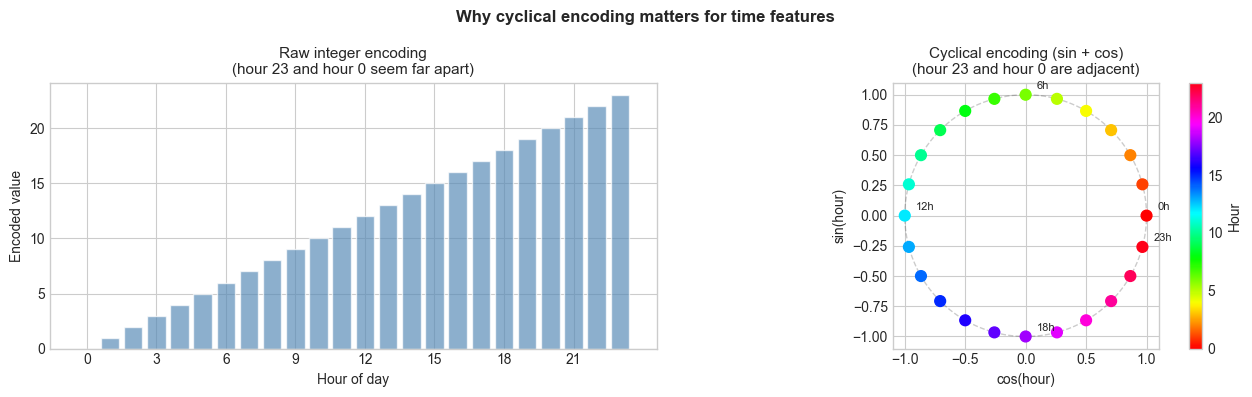

In [27]:
# This cell produces a chart that explains the concept visually.
# It's a great thing to show in an interview.

hours = np.arange(24)
# np.arange(24) creates [0, 1, 2, ..., 23] — integer hours

hour_sin = np.sin(2 * np.pi * hours / 24)
hour_cos = np.cos(2 * np.pi * hours / 24)
# np.sin() and np.cos() operate element-wise on arrays.
# 2 * np.pi is one full rotation (360°).
# Dividing by 24 maps the 24-hour cycle onto a full circle.

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: Raw integer encoding ────────────────────────────────────
axes[0].bar(hours, hours, color="#5B8DB8", alpha=0.7, edgecolor="white")
axes[0].set_title("Raw integer encoding\n(hour 23 and hour 0 seem far apart)", fontsize=11)
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Encoded value")
axes[0].set_xticks(range(0, 24, 3))

# ── Right: Cyclical encoding plotted on the unit circle ───────────
axes[1].scatter(hour_cos, hour_sin, c=hours, cmap="hsv", s=60, zorder=3)
# c=hours colours each point by hour value using the "hsv" colourmap.
# zorder=3 draws points on top of the grid lines.

for h in [0, 6, 12, 18, 23]:
    # Annotate a few key hours to show their position on the circle
    axes[1].annotate(
        f"{h}h",
        (hour_cos[h], hour_sin[h]),
        textcoords="offset points",   # Offset in points relative to the point
        xytext=(8, 4),
        fontsize=8
    )

# Draw the unit circle as a reference ring
theta = np.linspace(0, 2 * np.pi, 300)
axes[1].plot(np.cos(theta), np.sin(theta), "k--", alpha=0.2, linewidth=1)

axes[1].set_aspect("equal")   # Make the circle actually circular (not elliptical)
axes[1].set_title("Cyclical encoding (sin + cos)\n(hour 23 and hour 0 are adjacent)", fontsize=11)
axes[1].set_xlabel("cos(hour)")
axes[1].set_ylabel("sin(hour)")

plt.colorbar(axes[1].collections[0], ax=axes[1], label="Hour")

plt.suptitle("Why cyclical encoding matters for time features", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/03_cyclical_encoding_explainer.png", dpi=150, bbox_inches="tight")
plt.show()

In [28]:
# Extract raw time components from DateTime
df["Hour"]      = df["DateTime"].dt.hour
df["DayOfWeek"] = df["DateTime"].dt.dayofweek   # 0=Monday, 6=Sunday
df["Month"]     = df["DateTime"].dt.month        # 1=Jan, 12=Dec
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)
# .astype(int) converts True→1 and False→0.
# Models want numbers, not Python booleans (though many handle both).

# ── Cyclical encoding for Hour ────────────────────────────────────
df["Hour_sin"] = np.sin(2 * np.pi * df["Hour"] / 24)
df["Hour_cos"] = np.cos(2 * np.pi * df["Hour"] / 24)
# These two columns together encode the hour on a circle.
# A model using both captures the circular distance correctly.

# ── Cyclical encoding for Day of Week ────────────────────────────
df["DoW_sin"] = np.sin(2 * np.pi * df["DayOfWeek"] / 7)
df["DoW_cos"] = np.cos(2 * np.pi * df["DayOfWeek"] / 7)

# ── Cyclical encoding for Month ───────────────────────────────────
df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

# We KEEP the raw Hour, DayOfWeek, Month columns too.
# Tree-based models (Random Forest, XGBoost) can use raw integers
# just fine and don't benefit from cyclical encoding.
# We'll let the model decide which representation is more useful
# by including both.

time_feature_cols = [
    "Hour", "DayOfWeek", "Month", "IsWeekend",
    "Hour_sin", "Hour_cos", "DoW_sin", "DoW_cos", "Month_sin", "Month_cos"
]

print("Time features added:")
print(df[["DateTime"] + time_feature_cols].head(6).to_string())

Time features added:
             DateTime   Hour  DayOfWeek  Month  IsWeekend  Hour_sin  Hour_cos  DoW_sin  DoW_cos  Month_sin  Month_cos
0 2004-01-04 00:00:00 0.0000     6.0000 1.0000          1    0.0000    1.0000  -0.7818   0.6235     0.5000     0.8660
1 2004-01-04 01:00:00 1.0000     6.0000 1.0000          1    0.2588    0.9659  -0.7818   0.6235     0.5000     0.8660
2 2004-01-04 02:00:00 2.0000     6.0000 1.0000          1    0.5000    0.8660  -0.7818   0.6235     0.5000     0.8660
3 2004-01-04 03:00:00 3.0000     6.0000 1.0000          1    0.7071    0.7071  -0.7818   0.6235     0.5000     0.8660
4 2004-01-04 04:00:00 4.0000     6.0000 1.0000          1    0.8660    0.5000  -0.7818   0.6235     0.5000     0.8660
5 2004-01-04 05:00:00 5.0000     6.0000 1.0000          1    0.9659    0.2588  -0.7818   0.6235     0.5000     0.8660


---
## Step 3 — Lag Features

A **lag feature** is the value of a variable at a previous time step.

For example:
- `NO2_lag_1h` = the NO₂ reading from exactly 1 hour ago
- `NO2_lag_3h` = the NO₂ reading from 3 hours ago  
- `NO2_lag_24h` = the NO₂ reading from the same hour yesterday

**Why this is a "big data" concept:**
In streaming systems (Kafka, Spark Streaming), lag features are computed
in real-time using sliding windows over event streams. Here we compute them
offline on our full dataset, but the concept is identical — and showing
you understand temporal windowing is a strong signal to any DS interviewer.

**The critical warning — data leakage:**
When you create `NO2_lag_1h`, the first row will have NaN for this feature
(there is no "hour before" the first row). We must drop these rows AFTER
creating all lag features, not before. And we must do this BEFORE splitting
into train/test — the split must happen on the clean, feature-complete dataset.

In [29]:
# Define which columns to create lags for, and how many hours back.
# We focus on NO2 (our main prediction target) and CO (closely correlated).
# We also add lags for temperature and humidity (weather has lag effects too).

lag_configs = {
    "NO2(GT)":    [1, 2, 3, 6, 12, 24],
    # 1h, 2h, 3h: immediate recent context
    # 6h: half-day context
    # 12h: opposite-time-of-day context (morning vs evening)
    # 24h: same-time-yesterday (captures daily cycles)
    "CO(GT)":     [1, 3, 24],
    "NOx(GT)":    [1, 24],
    "T":          [1, 24],   # Temperature 1h ago and yesterday
    "RH":         [1, 24],   # Humidity 1h ago and yesterday
}

print("Creating lag features...")

for col, lags in lag_configs.items():
    for lag in lags:
        # Build the new column name: e.g. "NO2(GT)_lag_1h"
        # We replace special characters to make the name model-safe
        clean_col = col.replace("(", "").replace(")", "").replace(" ", "_")
        new_col_name = f"{clean_col}_lag_{lag}h"

        # .shift(n) shifts the column DOWN by n rows.
        # This means row i gets the value that was at row i-n.
        # In time-sorted data, this is the value from n hours ago.
        # The first n rows get NaN because there are no earlier rows.
        df[new_col_name] = df[col].shift(lag)

        # Example of what shift does:
        # Original:  [10, 12, 15, 8, 20]
        # shift(1):  [NaN, 10, 12, 15, 8]   ← each row gets previous row's value
        # shift(3):  [NaN, NaN, NaN, 10, 12] ← each row gets value from 3 rows back

print(f"\nLag features created. New shape: {df.shape}")

# Show what the lag columns look like
lag_preview_cols = ["DateTime", "NO2(GT)", "NOGT_lag_1h", "NOGT_lag_3h", "NOGT_lag_24h"] \
    if "NOGT_lag_1h" in df.columns else \
    ["DateTime", "NO2(GT)"] + [c for c in df.columns if "NO2GT_lag" in c or "NO2.GT._lag" in c][:3]

# More robust way to find lag columns:
no2_lag_cols = [c for c in df.columns if "NO2GT_lag" in c]
print("\nSample of NO2 lag features:")
print(df[["DateTime", "NO2(GT)"] + no2_lag_cols[:4]].head(10).to_string())
print("\nNote the NaN values in the first rows — these will be dropped later.")

Creating lag features...

Lag features created. New shape: (9357, 38)

Sample of NO2 lag features:
             DateTime  NO2(GT)  NO2GT_lag_1h  NO2GT_lag_2h  NO2GT_lag_3h  NO2GT_lag_6h
0 2004-01-04 00:00:00  86.0000           NaN           NaN           NaN           NaN
1 2004-01-04 01:00:00  70.0000       86.0000           NaN           NaN           NaN
2 2004-01-04 02:00:00  55.0000       70.0000       86.0000           NaN           NaN
3 2004-01-04 03:00:00  55.0000       55.0000       70.0000       86.0000           NaN
4 2004-01-04 04:00:00  49.0000       55.0000       55.0000       70.0000           NaN
5 2004-01-04 05:00:00  50.0000       49.0000       55.0000       55.0000           NaN
6 2004-01-04 06:00:00  67.0000       50.0000       49.0000       55.0000       86.0000
7 2004-01-04 07:00:00  94.0000       67.0000       50.0000       49.0000       70.0000
8 2004-01-04 08:00:00 119.0000       94.0000       67.0000       50.0000       55.0000
9 2004-01-04 09:00:00 139.0000 

---
## Step 4 — Rolling Window Features

A **rolling window** computes a statistic (mean, std, min, max) over
a sliding window of the N most recent rows.

- `NO2_rolling_3h_mean`: average NO₂ over the last 3 hours
- `NO2_rolling_24h_mean`: average NO₂ over the last 24 hours  
- `NO2_rolling_24h_std`: standard deviation of NO₂ over 24 hours

**Why rolling features are powerful:**
- The 3h mean captures the immediate trend (is pollution rising or falling?)
- The 24h mean captures the baseline level for that time of day
- The 24h std captures volatility — a stable day vs a day with pollution spikes

The difference between the current value and the rolling mean tells the model
whether this reading is unusually high or low compared to the recent context.

In [30]:
print("Creating rolling window features...")

# min_periods=1 means: compute the rolling stat even if the window
# isn't full yet (e.g. the 3h mean for row 1 uses just 1 value).
# Without this, the first window_size-1 rows would be NaN.
# We set min_periods=1 here to avoid creating extra NaN rows,
# though in practice the first few rows will still be dropped
# (due to lag NaNs) so it mainly helps with code cleanliness.

rolling_configs = [
    ("NO2(GT)", 3,  "mean"),   # 3-hour rolling mean
    ("NO2(GT)", 6,  "mean"),   # 6-hour rolling mean
    ("NO2(GT)", 24, "mean"),   # 24-hour rolling mean
    ("NO2(GT)", 24, "std"),    # 24-hour rolling standard deviation
    ("CO(GT)",  3,  "mean"),
    ("CO(GT)",  24, "mean"),
    ("T",       3,  "mean"),   # Temperature trend
    ("T",       24, "mean"),
]

for col, window, stat in rolling_configs:
    clean_col = col.replace("(", "").replace(")", "").replace(" ", "_")
    new_col_name = f"{clean_col}_rolling_{window}h_{stat}"

    # df[col].rolling(window=window) creates a Rolling object.
    # Calling .mean() or .std() on it computes the statistic
    # over the last `window` rows for every position.
    if stat == "mean":
        df[new_col_name] = df[col].rolling(window=window, min_periods=1).mean()
    elif stat == "std":
        df[new_col_name] = df[col].rolling(window=window, min_periods=2).std()
        # min_periods=2 for std because you need at least 2 values to compute
        # a standard deviation (variance requires n-1 degrees of freedom)

print(f"Rolling features created. New shape: {df.shape}")

# ── Bonus: Add rate-of-change feature ─────────────────────────────
# The difference between the current NO2 and 1 hour ago.
# A positive value means pollution is rising; negative means falling.
# This "derivative" gives the model information about trend direction.
df["NO2GT_change_1h"] = df["NO2(GT)"] - df["NO2(GT)"].shift(1)
# Subtracting the shifted column gives the 1-step difference.

df["NO2GT_change_3h"] = df["NO2(GT)"] - df["NO2(GT)"].shift(3)

print("\nNew feature columns added (sample):")
rolling_cols = [c for c in df.columns if "rolling" in c or "change" in c]
print(rolling_cols)

Creating rolling window features...
Rolling features created. New shape: (9357, 46)

New feature columns added (sample):
['NO2GT_rolling_3h_mean', 'NO2GT_rolling_6h_mean', 'NO2GT_rolling_24h_mean', 'NO2GT_rolling_24h_std', 'COGT_rolling_3h_mean', 'COGT_rolling_24h_mean', 'T_rolling_3h_mean', 'T_rolling_24h_mean', 'NO2GT_change_1h', 'NO2GT_change_3h']


---
## Step 5 — Define the Target Variable: AQI Category

We are building a **classification model** that predicts air quality category
from sensor readings and time/weather features.

We create an Air Quality Index (AQI) category label based on NO₂ concentration,
using the EU Air Quality Directive thresholds:

| Category | NO₂ range (µg/m³) | Meaning |
|----------|-------------------|---------|
| 0 — Good | 0–40 | Safe for everyone |
| 1 — Moderate | 40–100 | Sensitive groups may be affected |
| 2 — Poor | 100–200 | Health effects for general population |
| 3 — Very Poor | >200 | Serious health effects |

**Why classification and not regression?**
We will actually build BOTH in Phase 4. But for classification, the AQI
category label is more interpretable ("the air will be Poor tomorrow")
and more directly actionable than a raw µg/m³ number.

AQI category distribution:
  0 (Good      ):   350    3.7%  █
  1 (Moderate  ): 3,233   34.6%  █████████████████
  2 (Poor      ): 5,379   57.5%  ████████████████████████████
  3 (Very Poor ):   395    4.2%  ██


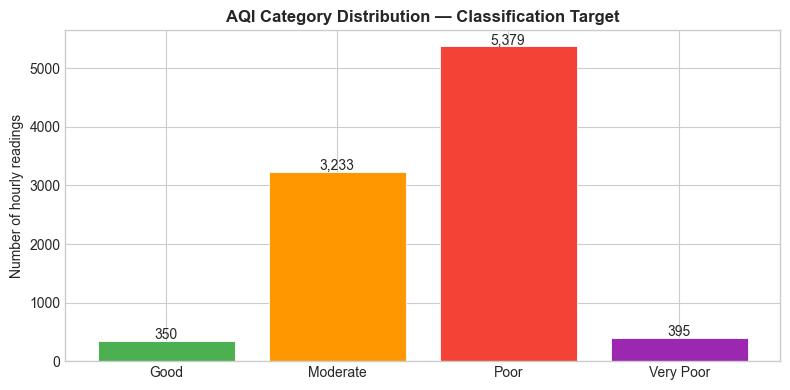


Note: class imbalance — we will handle this in Phase 4 with class weights.


In [31]:
def assign_aqi_category(no2_value):
    """
    Assigns an EU-standard AQI category based on NO₂ concentration.

    Args:
        no2_value: NO₂ concentration in µg/m³

    Returns:
        Integer category: 0=Good, 1=Moderate, 2=Poor, 3=Very Poor
    """
    if pd.isna(no2_value):
        return np.nan
    elif no2_value < 40:
        return 0   # Good
    elif no2_value < 100:
        return 1   # Moderate
    elif no2_value < 200:
        return 2   # Poor
    else:
        return 3   # Very Poor

# Apply the function row-by-row to create the target column.
# .apply(function) applies a function to each element in a Series.
df["AQI_category"] = df["NO2(GT)"].apply(assign_aqi_category)

# Also create a string label column for easy reading (used in charts)
aqi_label_map = {0: "Good", 1: "Moderate", 2: "Poor", 3: "Very Poor"}
df["AQI_label"] = df["AQI_category"].map(aqi_label_map)
# .map(dict) replaces each value in the Series using the dictionary as a lookup.

# ── Inspect the class distribution ───────────────────────────────
print("AQI category distribution:")
cat_counts = df["AQI_category"].value_counts().sort_index()
for cat_id, count in cat_counts.items():
    label = aqi_label_map.get(cat_id, "Unknown")
    pct   = count / len(df) * 100
    bar   = "█" * int(pct / 2)   # ASCII bar chart
    print(f"  {cat_id} ({label:10s}): {count:5,}  {pct:5.1f}%  {bar}")

# ── Visualise class distribution ──────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#4caf50", "#ff9800", "#f44336", "#9c27b0"]   # Green/Orange/Red/Purple
bars = ax.bar(
    [aqi_label_map[i] for i in sorted(aqi_label_map)],
    [cat_counts.get(i, 0) for i in sorted(aqi_label_map)],
    color=colors, edgecolor="white", linewidth=0.6
)
for bar, val in zip(bars, [cat_counts.get(i, 0) for i in sorted(aqi_label_map)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{val:,}", ha="center", fontsize=10)

ax.set_title("AQI Category Distribution — Classification Target", fontsize=12, fontweight="bold")
ax.set_ylabel("Number of hourly readings")
plt.tight_layout()
plt.savefig("../outputs/03_aqi_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nNote: class imbalance — we will handle this in Phase 4 with class weights.")

In [32]:
# Lag features with shift(24) create 24 NaN rows at the start.
# Rolling features with min_periods=1 don't add NaN rows.
# We must drop ALL rows that have any NaN in any feature column.
#
# IMPORTANT: We drop AFTER creating all features, not before.
# If we dropped early, we'd lose rows that could have valid lags
# computed from earlier rows.

rows_before = len(df)

# Drop rows where ANY feature column is NaN.
# We don't drop based on AQI_category — we handle NaN targets separately.
all_feature_cols = [c for c in df.columns
                    if c not in ["DateTime", "AQI_category", "AQI_label"]]

df_clean = df.dropna(subset=all_feature_cols + ["AQI_category"]).copy()
# subset= tells dropna() to only look at the specified columns.
# A row is only dropped if it has NaN in AT LEAST ONE of those columns.

df_clean = df_clean.reset_index(drop=True)

rows_after = len(df_clean)
rows_dropped = rows_before - rows_after

print(f"Rows before dropping NaN: {rows_before:,}")
print(f"Rows dropped (lag NaNs):  {rows_dropped:,}")
print(f"Rows remaining:           {rows_after:,}")
print(f"\nClean dataset: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")

# Confirm no NaNs remain in features
remaining_nans = df_clean[all_feature_cols].isnull().sum().sum()
print(f"NaN values remaining in features: {remaining_nans} ✓" if remaining_nans == 0
      else f"WARNING: {remaining_nans} NaN values still remain!")

Rows before dropping NaN: 9,357
Rows dropped (lag NaNs):  5,784
Rows remaining:           3,573

Clean dataset: 3,573 rows × 50 columns
NaN values remaining in features: 0 ✓


---
## Step 6 — Time-Aware Train / Validation / Test Split

**Why we cannot shuffle and randomly split time-series data:**

If we randomly sample 20% of rows as a test set, we might get:
- Training row from 15 March 2005 at 15:00
- Test row from 15 March 2005 at 14:00

The model would have trained on "the future" of its own test data.
This is called **data leakage** and makes your model evaluation meaninglessly
optimistic. Your model would appear to perform well in evaluation but
fail completely when deployed on truly unseen future data.

**The correct approach for time-series:**
- Sort by time (already done)
- Take the first 70% as training data
- Take the next 15% as validation data (for hyperparameter tuning in Phase 4)
- Take the final 15% as the test set (never touched until final evaluation)

This simulates real deployment: the model is trained on historical data
and evaluated on future data it has never seen.

In [33]:
# ── Define the final feature list ────────────────────────────────
# We exclude: DateTime (not a numeric feature), AQI_label (string duplicate
# of AQI_category), and NO2(GT) itself (we'd be predicting using the answer).
# We KEEP NO2(GT) lags and rolling features — those are past values, not the
# current target, so they don't cause leakage.

exclude_from_features = {
    "DateTime",
    "AQI_category",   # This IS our target — not a feature
    "AQI_label",      # String version of target
    "NO2(GT)",        # Current NO2 — this IS what we're predicting
    # We keep NO2 lags — those are PAST values, not the current value
}

FEATURE_COLS = [c for c in df_clean.columns if c not in exclude_from_features]
TARGET_COL   = "AQI_category"

print(f"Number of features: {len(FEATURE_COLS)}")
print("\nFeature columns:")
for i, col in enumerate(FEATURE_COLS):
    print(f"  {i+1:2d}. {col}")

Number of features: 46

Feature columns:
   1. CO(GT)
   2. PT08.S1(CO)
   3. C6H6(GT)
   4. PT08.S2(NMHC)
   5. NOx(GT)
   6. PT08.S3(NOx)
   7. PT08.S4(NO2)
   8. PT08.S5(O3)
   9. T
  10. RH
  11. AH
  12. Hour
  13. DayOfWeek
  14. Month
  15. IsWeekend
  16. Hour_sin
  17. Hour_cos
  18. DoW_sin
  19. DoW_cos
  20. Month_sin
  21. Month_cos
  22. NO2GT_lag_1h
  23. NO2GT_lag_2h
  24. NO2GT_lag_3h
  25. NO2GT_lag_6h
  26. NO2GT_lag_12h
  27. NO2GT_lag_24h
  28. COGT_lag_1h
  29. COGT_lag_3h
  30. COGT_lag_24h
  31. NOxGT_lag_1h
  32. NOxGT_lag_24h
  33. T_lag_1h
  34. T_lag_24h
  35. RH_lag_1h
  36. RH_lag_24h
  37. NO2GT_rolling_3h_mean
  38. NO2GT_rolling_6h_mean
  39. NO2GT_rolling_24h_mean
  40. NO2GT_rolling_24h_std
  41. COGT_rolling_3h_mean
  42. COGT_rolling_24h_mean
  43. T_rolling_3h_mean
  44. T_rolling_24h_mean
  45. NO2GT_change_1h
  46. NO2GT_change_3h


Time-aware split:
  Training:   2,501 rows  (2004-01-05 → 2004-12-07)
  Validation: 536 rows  (2004-12-07 → 2005-05-02)
  Test:       536 rows  (2005-05-02 → 2005-12-03)

X_train shape: (2501, 46)
X_val shape:   (536, 46)
X_test shape:  (536, 46)


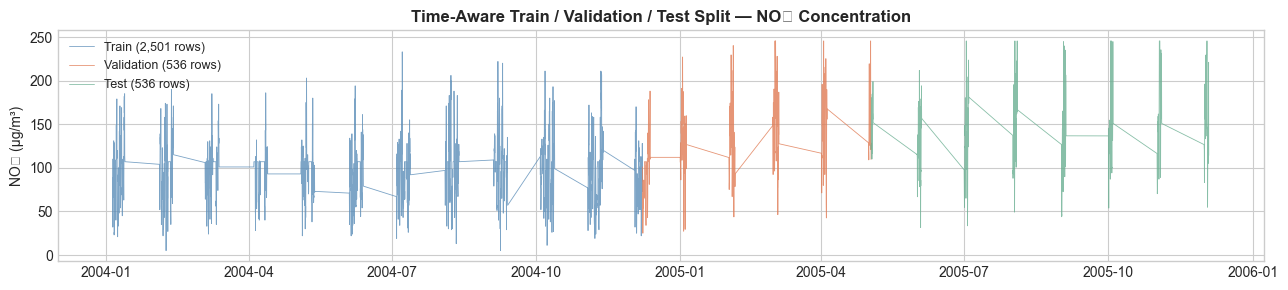

In [34]:
n = len(df_clean)
# Calculate split indices
train_end = int(n * 0.70)   # First 70% → training
val_end   = int(n * 0.85)   # Next 15% → validation
# Remaining 15% → test

# Slice the DataFrame using iloc (integer-location based indexing)
# iloc[start:end] selects rows from index start up to (but not including) end
df_train = df_clean.iloc[:train_end].copy()
df_val   = df_clean.iloc[train_end:val_end].copy()
df_test  = df_clean.iloc[val_end:].copy()

print("Time-aware split:")
print(f"  Training:   {len(df_train):,} rows  "
      f"({df_train['DateTime'].min().date()} → {df_train['DateTime'].max().date()})")
print(f"  Validation: {len(df_val):,} rows  "
      f"({df_val['DateTime'].min().date()} → {df_val['DateTime'].max().date()})")
print(f"  Test:       {len(df_test):,} rows  "
      f"({df_test['DateTime'].min().date()} → {df_test['DateTime'].max().date()})")

# ── Extract X (features) and y (target) for each split ───────────
X_train = df_train[FEATURE_COLS]
y_train = df_train[TARGET_COL]

X_val   = df_val[FEATURE_COLS]
y_val   = df_val[TARGET_COL]

X_test  = df_test[FEATURE_COLS]
y_test  = df_test[TARGET_COL]

# Convention: X = feature matrix (2D), y = target vector (1D)
print(f"\nX_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")

# ── Visualise the split ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 3))

# Plot a line of NO2 coloured by which split it belongs to
for subset, color, label in [
    (df_train, "#5B8DB8", f"Train ({len(df_train):,} rows)"),
    (df_val,   "#E07B54", f"Validation ({len(df_val):,} rows)"),
    (df_test,  "#6BAF92", f"Test ({len(df_test):,} rows)"),
]:
    ax.plot(subset["DateTime"], subset["NO2(GT)"],
            color=color, linewidth=0.6, alpha=0.8, label=label)

ax.set_title("Time-Aware Train / Validation / Test Split — NO₂ Concentration",
             fontsize=12, fontweight="bold")
ax.set_ylabel("NO₂ (µg/m³)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/03_train_val_test_split.png", dpi=150, bbox_inches="tight")
plt.show()

In [35]:
# StandardScaler: transforms each feature to have mean=0 and std=1.
#
# Formula: z = (x - mean) / std
#
# WHY SCALE?
# Without scaling, a feature with range [0, 2000] (like PT08 sensor values)
# dominates features with range [0, 1] (like IsWeekend).
# The model might learn to rely heavily on the large-range features simply
# because they numerically overpower the others — not because they're
# more predictive.
#
# CRITICAL RULE: Fit the scaler ONLY on training data.
# Then use that same fitted scaler to transform validation and test data.
# If you fit on all data (including test), you leak test statistics into
# training — the model has "seen" the test distribution.

scaler = StandardScaler()

# .fit_transform(X) does two things in one call:
# 1. fit: computes mean and std from X_train
# 2. transform: applies (x - mean) / std to every value in X_train
X_train_scaled = scaler.fit_transform(X_train)
# Result is a numpy array (not a DataFrame) — models accept both.

# .transform(X) applies the SAME mean/std learned from training data.
# We do NOT refit the scaler on val or test data.
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete.")
print(f"X_train_scaled mean (should be ≈0): {X_train_scaled.mean():.6f}")
print(f"X_train_scaled std  (should be ≈1): {X_train_scaled.std():.6f}")
print(f"X_val_scaled   mean (not guaranteed ≈0): {X_val_scaled.mean():.6f}")
# Validation mean won't be exactly 0 — it's scaled using training statistics,
# and validation data has a different distribution (it's from a later time period).
# That's expected and correct.

Scaling complete.
X_train_scaled mean (should be ≈0): -0.000000
X_train_scaled std  (should be ≈1): 1.000000
X_val_scaled   mean (not guaranteed ≈0): 0.087971


In [36]:
import joblib
# joblib is the standard library for saving Python objects (especially sklearn models
# and fitted transformers) to disk. It's more efficient than pickle for numpy arrays.
# If not installed: pip install joblib

# ── Save processed DataFrames as CSV ─────────────────────────────
df_train.to_csv("../data/processed/train.csv", index=False)
df_val.to_csv("../data/processed/val.csv",     index=False)
df_test.to_csv("../data/processed/test.csv",   index=False)

# ── Save the full engineered dataset (before split) ───────────────
df_clean.to_csv("../data/processed/features_full.csv", index=False)

# ── Save the fitted scaler ────────────────────────────────────────
# We save the fitted scaler so Phase 4 and the Streamlit app (Phase 6)
# can apply exactly the same transformation to new data.
# Without saving it, we'd have to refit — which recomputes mean/std
# and gives slightly different results, breaking consistency.
joblib.dump(scaler, "../data/processed/scaler.pkl")
# .pkl is the standard extension for pickled Python objects

# ── Save the feature column list ──────────────────────────────────
# Saving the feature list separately ensures Phase 4 uses
# EXACTLY the same columns in the same order.
import json
with open("../data/processed/feature_cols.json", "w") as f:
    json.dump(FEATURE_COLS, f, indent=2)
# json.dump() writes a Python object (list, dict, etc.) to a JSON file.
# indent=2 makes the file human-readable (pretty-printed with 2-space indent).

print("All files saved to data/processed/:")
for fname in sorted(os.listdir("../data/processed")):
    fpath = f"../data/processed/{fname}"
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {fname:<35} {size_kb:7.1f} KB")

All files saved to data/processed/:
  feature_cols.json                       0.8 KB
  features_full.csv                    1854.1 KB
  scaler.pkl                              2.5 KB
  test.csv                              294.2 KB
  train.csv                            1272.6 KB
  val.csv                               288.5 KB


In [37]:
# Show the final feature set, grouped by category.
# This is a great summary cell to have at the end of the notebook —
# it shows exactly what went into the model and why.

feature_groups = {
    "Sensor proxies (PT08)":   [c for c in FEATURE_COLS if "PT08" in c],
    "Ground-truth pollutants": [c for c in FEATURE_COLS if "(GT)" in c or "GT_" in c
                                 and "lag" not in c and "rolling" not in c],
    "Weather":                  [c for c in FEATURE_COLS if c in ["T", "RH", "AH"]],
    "Time (raw)":               [c for c in FEATURE_COLS if c in ["Hour","DayOfWeek","Month","IsWeekend"]],
    "Time (cyclical)":          [c for c in FEATURE_COLS if any(s in c for s in ["_sin","_cos"])],
    "Lag features":             [c for c in FEATURE_COLS if "lag" in c],
    "Rolling features":         [c for c in FEATURE_COLS if "rolling" in c],
    "Rate of change":           [c for c in FEATURE_COLS if "change" in c],
}

print("=" * 60)
print("FINAL FEATURE SET SUMMARY")
print("=" * 60)
total = 0
for group, cols in feature_groups.items():
    if cols:
        print(f"\n{group} ({len(cols)}):")
        for col in cols:
            print(f"  • {col}")
        total += len(cols)

print(f"\n{'='*60}")
print(f"Total features: {total}")
print(f"Training rows:  {len(X_train):,}")
print(f"Val rows:       {len(X_val):,}")
print(f"Test rows:      {len(X_test):,}")
print(f"\nTarget: AQI_category  (0=Good, 1=Moderate, 2=Poor, 3=Very Poor)")
print("=" * 60)
print("\nAll ready for Phase 4 — Modelling ✓")

FINAL FEATURE SET SUMMARY

Sensor proxies (PT08) (5):
  • PT08.S1(CO)
  • PT08.S2(NMHC)
  • PT08.S3(NOx)
  • PT08.S4(NO2)
  • PT08.S5(O3)

Ground-truth pollutants (5):
  • CO(GT)
  • C6H6(GT)
  • NOx(GT)
  • NO2GT_change_1h
  • NO2GT_change_3h

Weather (3):
  • T
  • RH
  • AH

Time (raw) (4):
  • Hour
  • DayOfWeek
  • Month
  • IsWeekend

Time (cyclical) (6):
  • Hour_sin
  • Hour_cos
  • DoW_sin
  • DoW_cos
  • Month_sin
  • Month_cos

Lag features (15):
  • NO2GT_lag_1h
  • NO2GT_lag_2h
  • NO2GT_lag_3h
  • NO2GT_lag_6h
  • NO2GT_lag_12h
  • NO2GT_lag_24h
  • COGT_lag_1h
  • COGT_lag_3h
  • COGT_lag_24h
  • NOxGT_lag_1h
  • NOxGT_lag_24h
  • T_lag_1h
  • T_lag_24h
  • RH_lag_1h
  • RH_lag_24h

Rolling features (8):
  • NO2GT_rolling_3h_mean
  • NO2GT_rolling_6h_mean
  • NO2GT_rolling_24h_mean
  • NO2GT_rolling_24h_std
  • COGT_rolling_3h_mean
  • COGT_rolling_24h_mean
  • T_rolling_3h_mean
  • T_rolling_24h_mean

Rate of change (2):
  • NO2GT_change_1h
  • NO2GT_change_3h

Total fe